In [1]:
import pandas as pd
import numpy as np
from sklearn.preprocessing import LabelEncoder,StandardScaler
from sklearn.impute import SimpleImputer

In [2]:
df=pd.read_csv("data.csv")
print(df)

     Unnamed: 0.1  Unnamed: 0   brand  \
0               0           0      HP   
1               1           1      HP   
2               2           2    Acer   
3               3           3  Lenovo   
4               4           4   Apple   
..            ...         ...     ...   
888           926        1015    Asus   
889           927        1016    Asus   
890           928        1017    Asus   
891           929        1018    Asus   
892           930        1019    Asus   

                                                  name   price  spec_rating  \
0                     Victus 15-fb0157AX Gaming Laptop   49900    73.000000   
1                                  15s-fq5007TU Laptop   39900    60.000000   
2                                 One 14 Z8-415 Laptop   26990    69.323529   
3                 Yoga Slim 6 14IAP8 82WU0095IN Laptop   59729    66.000000   
4                      MacBook Air 2020 MGND3HN Laptop   69990    69.323529   
..                               

In [3]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 893 entries, 0 to 892
Data columns (total 18 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   Unnamed: 0.1       893 non-null    int64  
 1   Unnamed: 0         893 non-null    int64  
 2   brand              893 non-null    object 
 3   name               893 non-null    object 
 4   price              893 non-null    int64  
 5   spec_rating        893 non-null    float64
 6   processor          893 non-null    object 
 7   CPU                893 non-null    object 
 8   Ram                893 non-null    object 
 9   Ram_type           893 non-null    object 
 10  ROM                893 non-null    object 
 11  ROM_type           893 non-null    object 
 12  GPU                893 non-null    object 
 13  display_size       893 non-null    float64
 14  resolution_width   893 non-null    float64
 15  resolution_height  893 non-null    float64
 16  OS                 893 non

In [4]:
df.head()

,Unnamed: 0.1,Unnamed: 0,brand,name,price,spec_rating,processor,CPU,Ram,Ram_type,ROM,ROM_type,GPU,display_size,resolution_width,resolution_height,OS,warranty
0,0,0,HP,Victus 15-fb0157AX Gaming Laptop,49900,73.000000,5th Gen AMD Ryzen 5 5600H,"Hexa Core, 12 Threads",8GB,DDR4,512GB,SSD,4GB AMD Radeon RX 6500M,15.6,1920.0,1080.0,Windows 11 OS,1
1,1,1,HP,15s-fq5007TU Laptop,39900,60.000000,12th Gen Intel Core i3 1215U,"Hexa Core (2P + 4E), 8 Threads",8GB,DDR4,512GB,SSD,Intel UHD Graphics,15.6,1920.0,1080.0,Windows 11 OS,1
2,2,2,Acer,One 14 Z8-415 Laptop,26990,69.323529,11th Gen Intel Core i3 1115G4,"Dual Core, 4 Threads",8GB,DDR4,512GB,SSD,Intel Iris Xe Graphics,14.0,1920.0,1080.0,Windows 11 OS,1
3,3,3,Lenovo,Yoga Slim 6 14IAP8 82WU0095IN Laptop,59729,66.000000,12th Gen Intel Core i5 1240P,"12 Cores (4P + 8E), 16 Threads",16GB,LPDDR5,512GB,SSD,Intel Integrated Iris Xe,14.0,2240.0,1400.0,Windows 11 OS,1
4,4,4,Apple,MacBook Air 2020 MGND3HN Laptop,69990,69.323529,Apple M1,Octa Core (4P + 4E),8GB,DDR4,256GB,SSD,Apple M1 Integrated Graphics,13.3,2560.0,1600.0,Mac OS,1


In [5]:
#unwanted unnamed 0 and unnamed 0.1
#dop unwanted columns
df=df.drop(columns=["Unnamed: 0","Unnamed: 0.1","name"])

In [6]:
#convert Ram from '8GB' to integer
df['Ram'] = df['Ram'].str.replace("GB","").astype(int)

In [7]:
df['ROM']=df['ROM'].replace({'1TB':'1024GB','2TB':'2048GB'})
df['ROM'] = df['ROM'].str.replace("GB","").astype(int)

In [8]:
label_cols=['brand','processor','CPU','Ram_type','ROM_type','GPU','OS']
le=LabelEncoder()
for col in label_cols:
    df[col]=le.fit_transform(df[col])

In [9]:
#handling missing value
imputer = SimpleImputer(strategy='most_frequent')
df_imputed = pd.DataFrame(imputer.fit_transform(df), columns=df.columns)

In [10]:
#scaler features
scaler=StandardScaler()
scaled_data=pd.DataFrame(scaler.fit_transform(df_imputed), columns=df.columns)
#view the result
print(scaled_data.head())

      brand     price  spec_rating  processor       CPU       Ram  Ram_type  \
0 -0.008833 -0.493170     0.653788   0.668538  0.381354 -0.811322 -0.733689   
1 -0.008833 -0.657520    -1.693439  -0.882691  0.273312 -0.811322 -0.733689   
2 -1.351417 -0.869695    -0.010020  -1.297808  0.165270 -0.811322 -0.733689   
3  0.830282 -0.331631    -0.610103  -0.773449 -1.023195  0.424517  1.795981   
4 -1.183594 -0.162992    -0.010020   1.870195  0.597439 -0.811322 -0.733689   

        ROM  ROM_type       GPU  display_size  resolution_width  \
0 -0.374433  0.155186 -1.724907      0.454147         -0.270979   
1 -0.374433  0.155186  1.216303      0.454147         -0.270979   
2 -0.374433  0.155186  1.133839     -1.250575         -0.270979   
3 -0.374433  0.155186  0.803984     -1.250575          0.480481   
4 -1.294293  0.155186  0.254225     -1.996392          1.231942   

   resolution_height        OS  warranty  
0          -0.423563  0.278430 -0.243311  
1          -0.423563  0.278430 -0.24

In [11]:
#split data
from sklearn.model_selection import train_test_split
X=scaled_data.drop('price',axis=1)#features
y=scaled_data['price']
X_train, X_test, y_train, y_test= train_test_split(X,y,test_size=0.2,random_state=42)

In [12]:
#train the model-LinearRegression
from sklearn.linear_model import LinearRegression
#step1:Create the model object
model=LinearRegression()
#step2: Train the model using training data
model.fit(X_train,y_train)

,"fit_intercept fit_intercept: bool, default=TrueWhether to calculate the intercept for this model. If setto False, no intercept will be used in calculations(i.e. data is expected to be centered).",True
,"copy_X copy_X: bool, default=TrueIf True, X will be copied; else, it may be overwritten.",True
,"tol tol: float, default=1e-6The precision of the solution (`coef_`) is determined by `tol` whichspecifies a different convergence criterion for the `lsqr` solver.`tol` is set as `atol` and `btol` of :func:`scipy.sparse.linalg.lsqr` whenfitting on sparse training data. This parameter has no effect when fittingon dense data... versionadded:: 1.7",1e-06
,"n_jobs n_jobs: int, default=NoneThe number of jobs to use for the computation. This will only providespeedup in case of sufficiently large problems, that is if firstly`n_targets > 1` and secondly `X` is sparse or if `positive` is setto `True`. ``None`` means 1 unless in a:obj:`joblib.parallel_backend` context. ``-1`` means using allprocessors. See :term:`Glossary ` for more details.",None
,"positive positive: bool, default=FalseWhen set to ``True``, forces the coefficients to be positive. Thisoption is only supported for dense arrays.For a comparison between a linear regression model with positive constraintson the regression coefficients and a linear regression without such constraints,see :ref:`sphx_glr_auto_examples_linear_model_plot_nnls.py`... versionadded:: 0.24",False


In [13]:
y_pred=model.predict(X_test)

In [14]:
model.score(X_train,y_train)

0.7400124980178061

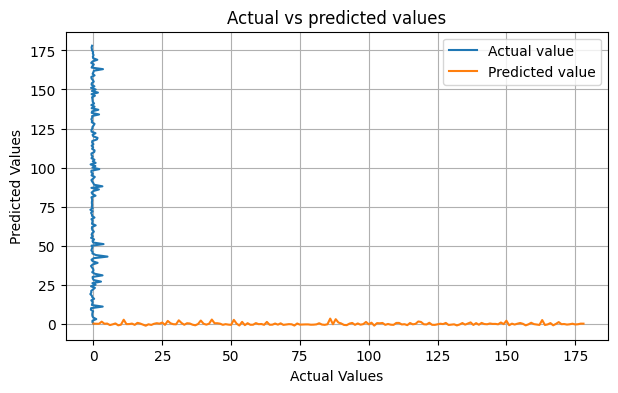

In [16]:
import matplotlib.pyplot as plt
index=np.arange(len(y_test))
plt.figure(figsize=(7,4))
plt.plot(y_test,index,label='Actual value')
plt.plot(index,y_pred,label='Predicted value')
plt.xlabel("Actual Values")
plt.ylabel("Predicted Values")
plt.title("Actual vs predicted values")
plt.legend()
plt.grid(True)
plt.show()